All Libraries

In [21]:
import random
import numpy as np
import pandas as pd
import os
from pathlib import Path
from typing import Optional
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

#Set seed
SEED = 123
random.seed(SEED)
np.random.seed(SEED)

Global Variable

In [22]:
# 1) Path to your CSV file
DATASET_PATH = Path("../Datasets/Final_Modelling_Dataset.csv")

# 2) Target column name
TARGET_VARIABLE = "Alzheimer.s.Diagnosis"

# 3) Columns to drop before analysis (IDs / metadata). Keep as a Python list.
EXCLUDE_COLUMNS = []  # e.g., ["ID", "RecordNo"]

# 4) Output folder (created if missing)
OUTDIR = Path("../All Reports/4. Supervised ML and DL Reports")
OUTDIR.mkdir(parents=True, exist_ok=True)

Load the dataset

In [23]:
# Function to load a CSV file into a pandas DataFrame
def load_data(path):
    return pd.read_csv(
        path,
        # Explicit NA values — match R behavior for blanks, "NA", and spaces
        na_values=["", "NA", " "],
        # Prevent Pandas from treating "None" (and other strings) as missing
        # This ensures "None" stays as a valid category label for EducationLevel, etc.
        keep_default_na=False
    )

# Load and inspect using the configured path
df = load_data(DATASET_PATH)

Converting our target variable to binary 0/1 as it is important for NN or SVM.

In [24]:
def binarize_target_simple(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """
    Convert a binary target column with 'Yes'/'No' to {0,1}.
    Returns a new DataFrame with the converted column.
    """
    mapping = {"No": 0, "Yes": 1}
    out = df.copy()
    out[target_col] = out[target_col].map(mapping).astype("Int8")
    return out

# --- Usage ---
df = binarize_target_simple(df, TARGET_VARIABLE)


Logistic Regression


=== Logistic Regression Results ===

Confusion Matrix:
            Pred_No  Pred_Yes
Actual_No       781       197
Actual_Yes      212       766

Classification Report:
              precision  recall  f1-score    support
No               0.7865  0.7986    0.7925   978.0000
Yes              0.7954  0.7832    0.7893   978.0000
accuracy         0.7909  0.7909    0.7909     0.7909
macro avg        0.7910  0.7909    0.7909  1956.0000
weighted avg     0.7910  0.7909    0.7909  1956.0000

ROC AUC: 0.8718



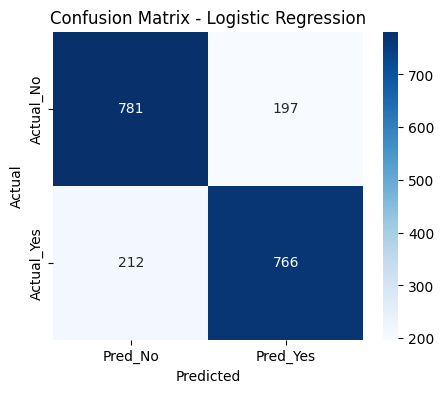

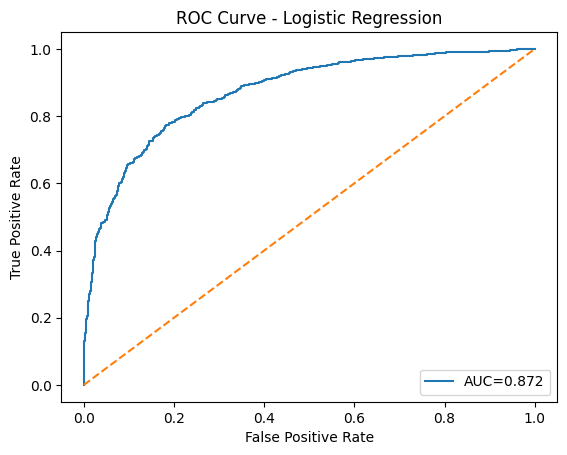

In [25]:
def run_logistic_regression(
    df: pd.DataFrame,
    target_col: str,
    exclude_cols: Optional[list] = None,
    test_size: float = 0.3,
    outdir: Optional[Path] = None,
    seed: int = SEED
):
    """
    Runs logistic regression with:
    - Binary target conversion (Yes/No → 1/0, or numeric 0/1 preserved)
    - Optional exclusion of ID/metadata columns
    - Standard scaling of numeric predictors
    - Train/test split
    - Saves evaluation metrics & plots to OUTDIR
    - Prints outputs neatly in the IDE
    """

    exclude_cols = exclude_cols or []
    df_copy = df.copy()

    # --- 0) Convert target to 0/1 ---
    if df_copy[target_col].dtype == object:
        df_copy[target_col] = df_copy[target_col].map(
            {"No": 0, "Yes": 1, "no": 0, "yes": 1}
        ).astype(int)
    else:
        df_copy[target_col] = df_copy[target_col].astype(int)

    # --- 1) Drop excluded columns ---
    X = df_copy.drop(columns=[target_col, *exclude_cols])
    y = df_copy[target_col]

    # --- 2) Scale numeric columns ---
    num_cols = X.select_dtypes(include=[np.number]).columns
    scaler = StandardScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])

    # --- 3) Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )

    # --- 4) Fit logistic regression ---
    model = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=seed)
    model.fit(X_train, y_train)

    # --- 5) Predictions ---
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= 0.5).astype(int)

    # --- 6) Metrics ---
    cm = confusion_matrix(y_test, y_pred)
    report_df = pd.DataFrame(classification_report(y_test, y_pred, target_names=["No", "Yes"], output_dict=True)).transpose()
    roc_auc = roc_auc_score(y_test, y_probs)

    # --- Print outputs to IDE ---
    print("\n=== Logistic Regression Results ===")
    print("\nConfusion Matrix:")
    print(pd.DataFrame(cm, index=["Actual_No", "Actual_Yes"], columns=["Pred_No", "Pred_Yes"]))
    print("\nClassification Report:")
    print(report_df.round(4))
    print(f"\nROC AUC: {roc_auc:.4f}\n")

    # --- Plot Confusion Matrix ---
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred_No", "Pred_Yes"],
                yticklabels=["Actual_No", "Actual_Yes"])
    plt.title("Confusion Matrix - Logistic Regression")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    if outdir:
        plt.savefig(outdir / "logreg_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    # --- ROC curve ---
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Logistic Regression")
    plt.legend(loc="lower right")
    if outdir:
        plt.savefig(outdir / "logreg_roc_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    # --- Save numeric outputs ---
    if outdir:
        outdir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(cm, index=["Actual_No", "Actual_Yes"], columns=["Pred_No", "Pred_Yes"]) \
            .to_csv(outdir / "logreg_confusion_matrix.csv")
        report_df.to_csv(outdir / "logreg_classification_report.csv")
        with open(outdir / "logreg_auc.txt", "w") as f:
            f.write(f"AUC: {roc_auc:.4f}\n")

    return {
        "model": model,
        "confusion_matrix": cm,
        "classification_report": report_df,
        "roc_auc": roc_auc
    }

# --- Usage Example ---
results = run_logistic_regression(
    df=df,
    target_col=TARGET_VARIABLE,
    exclude_cols=EXCLUDE_COLUMNS,
    outdir=OUTDIR
)



=== Random Forest Results ===

Confusion Matrix:
            Pred_No  Pred_Yes
Actual_No       817       161
Actual_Yes      181       797

Classification Report:
              precision  recall  f1-score    support
No               0.8186  0.8354    0.8269   978.0000
Yes              0.8319  0.8149    0.8233   978.0000
accuracy         0.8252  0.8252    0.8252     0.8252
macro avg        0.8253  0.8252    0.8251  1956.0000
weighted avg     0.8253  0.8252    0.8251  1956.0000

ROC AUC: 0.8962



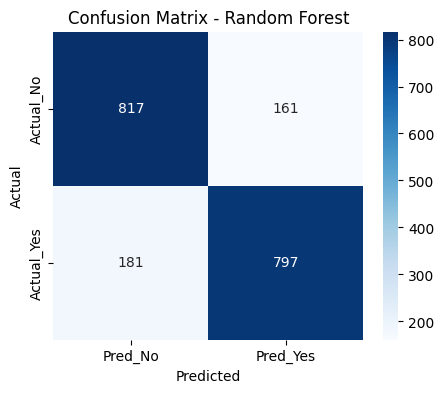

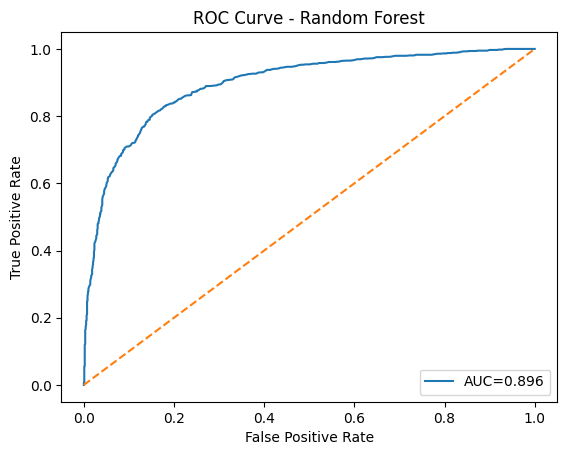

In [26]:
def run_random_forest(
    df: pd.DataFrame,
    target_col: str,
    exclude_cols: Optional[list] = None,
    test_size: float = 0.3,
    outdir: Optional[Path] = None,
    seed: int = SEED,
    n_estimators: int = 500,
    max_features: str = "sqrt"
):
    """
    Runs Random Forest with:
    - Binary target conversion (Yes/No → 1/0, or numeric 0/1 preserved)
    - Optional exclusion of ID/metadata columns
    - Standard scaling of numeric predictors (optional but kept consistent)
    - Train/test split
    - Saves evaluation metrics & plots to OUTDIR
    - Prints outputs neatly in the IDE
    """

    exclude_cols = exclude_cols or []
    df_copy = df.copy()

    # --- 0) Convert target to 0/1 ---
    if df_copy[target_col].dtype == object:
        df_copy[target_col] = df_copy[target_col].map(
            {"No": 0, "Yes": 1, "no": 0, "yes": 1}
        ).astype(int)
    else:
        df_copy[target_col] = df_copy[target_col].astype(int)

    # --- 1) Drop excluded columns ---
    X = df_copy.drop(columns=[target_col, *exclude_cols])
    y = df_copy[target_col]

    # --- 2) Scale numeric columns ---
    num_cols = X.select_dtypes(include=[np.number]).columns
    scaler = StandardScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])

    # --- 3) Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )

    # --- 4) Fit Random Forest ---
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_features=max_features,
        random_state=seed,
        class_weight="balanced",
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    # --- 5) Predictions ---
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= 0.5).astype(int)

    # --- 6) Metrics ---
    cm = confusion_matrix(y_test, y_pred)
    report_df = pd.DataFrame(classification_report(y_test, y_pred, target_names=["No", "Yes"], output_dict=True)).transpose()
    roc_auc = roc_auc_score(y_test, y_probs)

    # --- Print outputs to IDE ---
    print("\n=== Random Forest Results ===")
    print("\nConfusion Matrix:")
    print(pd.DataFrame(cm, index=["Actual_No", "Actual_Yes"], columns=["Pred_No", "Pred_Yes"]))
    print("\nClassification Report:")
    print(report_df.round(4))
    print(f"\nROC AUC: {roc_auc:.4f}\n")

    # --- Plot Confusion Matrix ---
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred_No", "Pred_Yes"],
                yticklabels=["Actual_No", "Actual_Yes"])
    plt.title("Confusion Matrix - Random Forest")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    if outdir:
        plt.savefig(outdir / "rf_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    # --- ROC curve ---
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Random Forest")
    plt.legend(loc="lower right")
    if outdir:
        plt.savefig(outdir / "rf_roc_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    # --- Save numeric outputs ---
    if outdir:
        outdir.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(cm, index=["Actual_No", "Actual_Yes"], columns=["Pred_No", "Pred_Yes"]) \
            .to_csv(outdir / "rf_confusion_matrix.csv")
        report_df.to_csv(outdir / "rf_classification_report.csv")
        with open(outdir / "rf_auc.txt", "w") as f:
            f.write(f"AUC: {roc_auc:.4f}\n")

    return {
        "model": model,
        "confusion_matrix": cm,
        "classification_report": report_df,
        "roc_auc": roc_auc
    }

# --- Usage Example ---
rf_results = run_random_forest(
    df=df,
    target_col=TARGET_VARIABLE,
    exclude_cols=EXCLUDE_COLUMNS,
    outdir=OUTDIR
)
